In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from tqdm import tqdm
from medmnist import BloodMNIST
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

In [2]:
# Device and seed settings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
manualSeed = 999
torch.manual_seed(manualSeed)

In [3]:
# Hyperparameters
num_epochs = 50
batch_size = 64
lr = 0.0002
beta1 = 0.5
latent_dim = 100

In [4]:
# Output directories (adjust path as needed)
output_dir = r"D:\One Drive\OneDrive\Desktop\College\3rd Year\6th Sem\GAN\Assignment 4\Output"
os.makedirs(output_dir, exist_ok=True)
gan_types = ['LSGAN', 'WGAN', 'WGAN_GP']
for gan in gan_types:
    os.makedirs(os.path.join(output_dir, gan, "checkpoints"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, gan, "images"), exist_ok=True)

In [5]:
# Data loading: resize to 64x64 and convert to 3 channels
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
dataset = BloodMNIST(split='train', transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

In [6]:
# Weight initialization
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [7]:
# Generator (DCGAN-style) with 3-channel output
class Generator(nn.Module):
    def __init__(self, nz=latent_dim, ngf=64, nc=3):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # Output: (nc) x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

# Discriminator (DCGAN-style) updated for 3 channels
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False)
            # Output is not passed through an activation here
        )

    def forward(self, input):
        return self.main(input).view(-1)


In [8]:
# Initialize models
def init_models():
    netG = Generator().to(device)
    netD = Discriminator().to(device)
    netG.apply(weights_init)
    netD.apply(weights_init)
    return netG, netD


In [9]:
# Utility to generate and save images
def save_generated_images(netG, epoch, gan_type, num_images=64):
    netG.eval()
    fixed_noise = torch.randn(num_images, latent_dim, 1, 1, device=device)
    with torch.no_grad():
        fake = netG(fixed_noise).detach().cpu()
    img_filename = os.path.join(output_dir, gan_type, "images", f"epoch_{epoch:03d}.png")
    vutils.save_image(fake, img_filename, normalize=True, nrow=8)
    netG.train()

In [10]:
# Utility to save checkpoints
def save_checkpoint(netG, netD, epoch, gan_type):
    ckpt_path = os.path.join(output_dir, gan_type, "checkpoints", f"epoch_{epoch:03d}.pth")
    torch.save({
        'epoch': epoch,
        'netG_state_dict': netG.state_dict(),
        'netD_state_dict': netD.state_dict()
    }, ckpt_path)

In [11]:
# Gradient penalty for WGAN-GP
def compute_gradient_penalty(netD, real_samples, fake_samples):
    alpha = torch.rand(real_samples.size(0), 1, 1, 1, device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = netD(interpolates)
    fake = torch.ones(d_interpolates.size(), device=device)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

Training LSGAN ...


Epoch 10: Checkpoint and images saved for LSGAN.


Epoch 20: Checkpoint and images saved for LSGAN.


Epoch 30: Checkpoint and images saved for LSGAN.


Epoch 40: Checkpoint and images saved for LSGAN.


...

Epoch 10: Checkpoint and images saved for WGAN_GP.


Epoch 20: Checkpoint and images saved for WGAN_GP.


Epoch 30: Checkpoint and images saved for WGAN_GP.


Epoch 40: Checkpoint and images saved for WGAN_GP.


Epoch 50: Checkpoint and images saved for WGAN_GP.
Evaluating WGAN_GP ...
WGAN_GP - Inception Score: 2.6011, FID: 242.8653


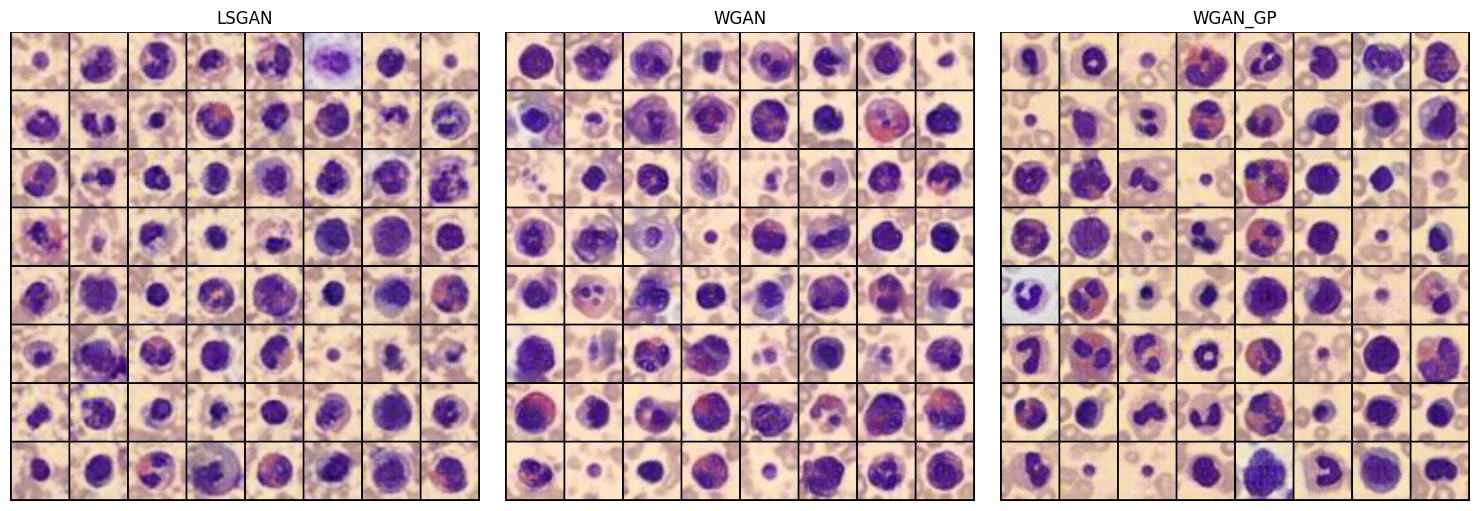

Training and evaluation complete. Check the output folder for checkpoints, images, and metrics.


In [12]:
# Training routine with error handling and checkpoint resume
def train_gan(gan_type='LSGAN'):
    print(f"Training {gan_type} ...")
    netG, netD = init_models()

    optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
    optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
    
    criterion = nn.MSELoss().to(device)
    lambda_gp = 10  # For WGAN-GP

    G_losses = []
    D_losses = []

    start_epoch = 1
    current_epoch = start_epoch

    while current_epoch <= num_epochs:
        try:
            for epoch in range(current_epoch, num_epochs+1):
                progress_bar = tqdm(dataloader, desc=f"{gan_type} Epoch {epoch}/{num_epochs}", leave=False)
                for i, (data, _) in enumerate(progress_bar):
                    real = data.to(device)
                    b_size = real.size(0)
                    netD.zero_grad()
                    noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
                    fake = netG(noise)

                    # Update Discriminator based on GAN type
                    if gan_type == 'LSGAN':
                        real_label = torch.ones(b_size, device=device)
                        fake_label = torch.zeros(b_size, device=device)
                        output_real = netD(real)
                        loss_D_real = 0.5 * criterion(output_real, real_label)
                        output_fake = netD(fake.detach())
                        loss_D_fake = 0.5 * criterion(output_fake, fake_label)
                        loss_D = loss_D_real + loss_D_fake
                    elif gan_type == 'WGAN':
                        loss_D = -torch.mean(netD(real)) + torch.mean(netD(fake.detach()))
                    elif gan_type == 'WGAN_GP':
                        loss_D = -torch.mean(netD(real)) + torch.mean(netD(fake.detach()))
                        gp = compute_gradient_penalty(netD, real.data, fake.data)
                        loss_D += lambda_gp * gp
                    else:
                        raise ValueError("Invalid gan_type.")

                    loss_D.backward()
                    optimizerD.step()

                    # For WGAN, clip weights
                    if gan_type == 'WGAN':
                        for p in netD.parameters():
                            p.data.clamp_(-0.01, 0.01)

                    # Update Generator
                    netG.zero_grad()
                    noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
                    fake = netG(noise)
                    if gan_type == 'LSGAN':
                        output = netD(fake)
                        loss_G = 0.5 * criterion(output, torch.ones(b_size, device=device))
                    elif gan_type in ['WGAN', 'WGAN_GP']:
                        loss_G = -torch.mean(netD(fake))
                    else:
                        raise ValueError("Invalid gan_type.")
                    loss_G.backward()
                    optimizerG.step()

                    G_losses.append(loss_G.item())
                    D_losses.append(loss_D.item())
                    progress_bar.set_postfix({"loss_G": loss_G.item(), "loss_D": loss_D.item()})
                
                # Save checkpoint and images every 10 epochs or on final epoch
                if epoch % 10 == 0 or epoch == num_epochs:
                    save_checkpoint(netG, netD, epoch, gan_type)
                    save_generated_images(netG, epoch, gan_type)
                    print(f"Epoch {epoch}: Checkpoint and images saved for {gan_type}.")
                current_epoch = epoch + 1
            break  # Exit the while loop if training completes without error

        except Exception as e:
            print(f"Error encountered at epoch {epoch}: {e}")
            last_ckpt_epoch = (epoch // 10) * 10
            if last_ckpt_epoch == 0:
                print("No checkpoint available to resume. Exiting training.")
                raise e
            else:
                print(f"Resuming training from epoch {last_ckpt_epoch + 1} using checkpoint.")
                ckpt_path = os.path.join(output_dir, gan_type, "checkpoints", f"epoch_{last_ckpt_epoch:03d}.pth")
                checkpoint = torch.load(ckpt_path)
                netG.load_state_dict(checkpoint['netG_state_dict'])
                netD.load_state_dict(checkpoint['netD_state_dict'])
                current_epoch = last_ckpt_epoch + 1
                optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
                optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
                # Continue training

    # Evaluation using Inception Score (IS) and FID
    print(f"Evaluating {gan_type} ...")
    netG.eval()
    num_eval = 1000
    eval_noise = torch.randn(num_eval, latent_dim, 1, 1, device=device)
    with torch.no_grad():
        fake_images = netG(eval_noise).cpu()
    fake_images = (fake_images + 1) / 2.0  # Scale to [0, 1]

    # Gather a set of real images (up to num_eval)
    real_images_list = []
    total = 0
    for batch in dataloader:
        imgs, _ = batch
        real_images_list.append(imgs)
        total += imgs.size(0)
        if total >= num_eval:
            break
    real_images = torch.cat(real_images_list, dim=0)[:num_eval]
    real_images = (real_images + 1) / 2.0

    # Clear GPU cache to free memory before evaluation
    torch.cuda.empty_cache()

    # Initialize metrics on CPU to reduce GPU memory usage
    fid_metric = FrechetInceptionDistance(normalize=True).to("cpu")
    is_metric = InceptionScore().to("cpu")

    # Update metrics in small batches to avoid OOM
    eval_batch = 100
    for i in range(0, num_eval, eval_batch):
        real_batch = real_images[i:i+eval_batch].to("cpu")
        fake_batch = fake_images[i:i+eval_batch].to("cpu")
        # Update FID metric separately for real and fake images
        fid_metric.update(real_batch, real=True)
        fid_metric.update(fake_batch, real=False)
        # Convert fake_batch to uint8 for Inception Score (expected in [0, 255])
        fake_batch_uint8 = (fake_batch * 255).round().clamp(0, 255).to(torch.uint8)
        is_metric.update(fake_batch_uint8)

    fid_value = fid_metric.compute().item()
    is_value, is_std = is_metric.compute()
    is_value = is_value.item()

    print(f"{gan_type} - Inception Score: {is_value:.4f}, FID: {fid_value:.4f}")

    # Save evaluation metrics
    with open(os.path.join(output_dir, gan_type, f"{gan_type}_metrics.txt"), "w") as f:
        f.write(f"Inception Score: {is_value:.4f}\n")
        f.write(f"FID: {fid_value:.4f}\n")
    
    return netG, netD, G_losses, D_losses

if __name__ == "__main__":
    results = {}
    for gan in gan_types:
        netG, netD, G_losses, D_losses = train_gan(gan_type=gan)
        results[gan] = {"netG": netG, "netD": netD, "G_losses": G_losses, "D_losses": D_losses}

    # Final visualization of generated images from each GAN variant
    fig, axes = plt.subplots(1, len(gan_types), figsize=(15, 5))
    for ax, gan in zip(axes, gan_types):
        img_path = os.path.join(output_dir, gan, "images", f"epoch_{num_epochs:03d}.png")
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.set_title(gan)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "final_generated_comparison.png"))
    plt.show()

    print("Training and evaluation complete. Check the output folder for checkpoints, images, and metrics.")